<a href="https://colab.research.google.com/github/Shivssv1012/Deep-Learning-/blob/main/Early_Stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [2]:
X, y =make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

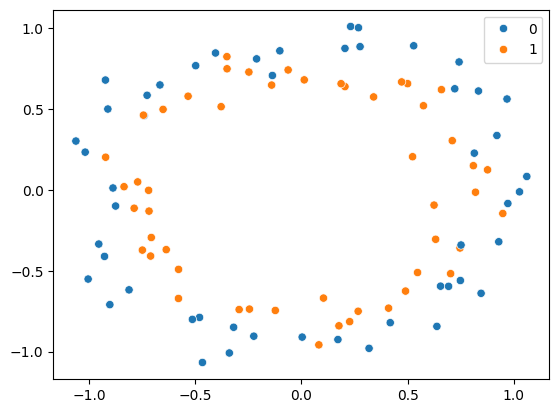

In [7]:
sns.scatterplot(x=X[:,0],y=X[:,1], hue=y)

In [8]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=2)

In [24]:
model=Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))

model.add(Dense(1, activation='sigmoid'))


In [25]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [26]:
history=model.fit(X_train, y_train, epochs=3500, validation_data=(X_test, y_test), verbose=0)

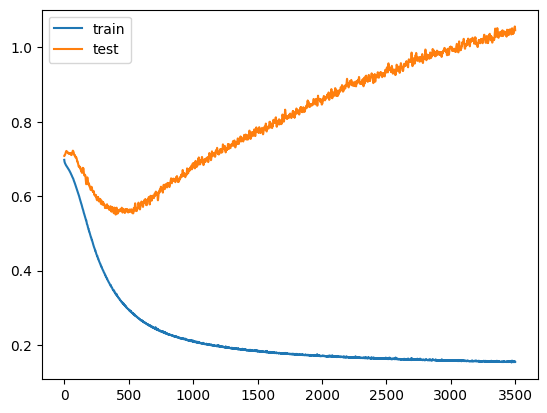

In [27]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


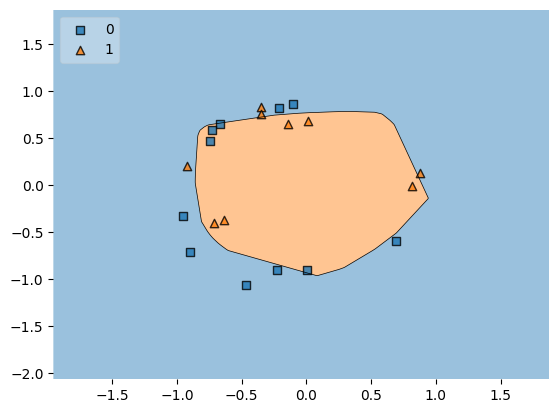

In [28]:
plot_decision_regions(X_test,y_test.ravel(), clf=model, legend=2)
plt.show()

Early Stopping


In [55]:
model=Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [56]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [59]:
callback=EarlyStopping(
    monitor='val_loss',
    patience=40,
    min_delta=0.00001,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [60]:
history=model.fit(X_train, y_train, epochs=3500, validation_data=(X_test, y_test),callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5625 - loss: 0.6742 - val_accuracy: 0.4000 - val_loss: 0.7222
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6737 - val_accuracy: 0.4000 - val_loss: 0.7238
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5625 - loss: 0.6731 - val_accuracy: 0.4000 - val_loss: 0.7245
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5625 - loss: 0.6728 - val_accuracy: 0.4000 - val_loss: 0.7254
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5875 - loss: 0.6721 - val_accuracy: 0.3500 - val_loss: 0.7262
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5875 - loss: 0.6716 - val_accuracy: 0.3500 - val_loss: 0.7275
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5875 - loss: 0.6710 - val_accuracy: 0.3500 - val_loss: 0.7277
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6000 - loss: 0.6704 - val_accuracy: 0.3500 - v

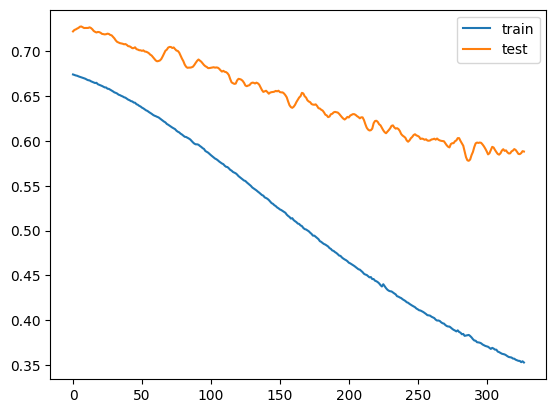

In [61]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


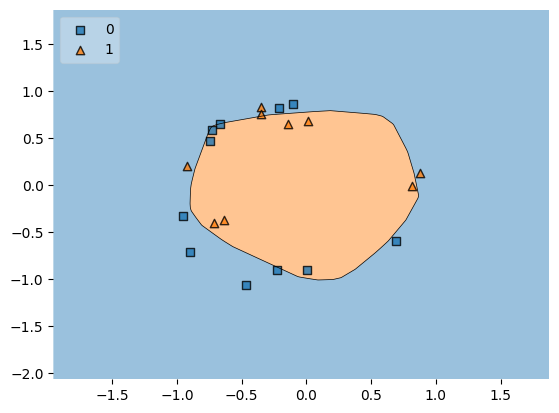

In [62]:
plot_decision_regions(X_test,y_test.ravel(), clf=model, legend=2)
plt.show()